In [1]:
from platform_utils import print_info

print_info()



macOS-14.2.1-arm64-arm-64bit
======================================== System Information ========================================
System: Darwin
Release: 23.2.0
Version: Darwin Kernel Version 23.2.0: Wed Nov 15 21:54:51 PST 2023; root:xnu-10002.61.3~2/RELEASE_ARM64_T6030
Machine: arm64
Processor: arm
======================================== CPU Info ========================================
Physical cores: 12
Total cores: 12
Max Frequency: 4056.00Mhz
Min Frequency: 696.00Mhz
Current Frequency: 4056.00Mhz
======================================== Memory Information ========================================
Total: 18.00GB
Available: 6.63GB
Used: 8.05GB
Percentage: 63.2%


In [4]:
REPEAT = 3

In [30]:
%pip install matplotlib
%pip install numpy
%pip install selenium
%pip install psrecord
%pip install pandas




Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# run web server in separate thread

import subprocess
import os

server_cmd = "python3 -m http.server 5500 -d ../"

server = subprocess.Popen(server_cmd.split(), cwd=os.getcwd())




Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/server.py", line 1314, in <module>
    test(
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/server.py", line 1261, in test
    with ServerClass(addr, HandlerClass) as httpd:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/socketserver.py", line 457, in __init__
    self.server_bind()
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/server.py", line 1308, in server_bind
    return super().server_bind()
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Vers

In [5]:

import time
from selenium_utils import create_firefox_driver, create_chromium_driver
    
def execute_test(driver, name,url, folder):
    log_name = name.lower()
    subprocess.Popen(
        f"psrecord {driver.service.process.pid} --log {folder}/{log_name}.usage.log --include-children".split(
            " "
        )
    )

    driver.set_script_timeout(30)
    driver.get(f"http://127.0.0.1:5500/{url}")
    
    time.sleep(30)

    driver.close()
    
def run_test(folder,test_suffix):
    url =f"test_python/{folder}/index.html"
    results = f'./{folder}/results/n_{test_suffix}'
    os.makedirs(results, exist_ok=True)
    execute_test(create_firefox_driver(), "firefox",url,results)

    execute_test(create_chromium_driver(), "chromium",url,results)




In [ ]:

for i in range( REPEAT):
    run_test("empty_page",i)

In [9]:
n_threads = [1]


for n_thread in n_threads:
    for i in range( REPEAT):
        print(f'Running test with {n_thread} threads')
        #clear output directory
        subprocess.call('rm -rf ./output/*', shell=True)
        
        subprocess.call(f'python3 test.py --n_threads {n_thread} --beam_on 1 --test "firefox chromium" --particle geantino', shell=True)
        
        folder_output_name = f'./results_1_shot/thread_{n_thread}/n_{i}'
        
        os.makedirs(folder_output_name, exist_ok=True)
        
        # copy the output files to the results directory
        subprocess.call(f'cp ./output/* {folder_output_name}', shell=True)

Running test with 1 threads
Attaching to process 78240
Attaching to process 78336
Running test with 1 threads
Attaching to process 78422
Attaching to process 78511
Running test with 1 threads
Attaching to process 78595
Attaching to process 78687


In [117]:
n_threads = [1]


for n_thread in n_threads:
    for i in range( REPEAT):
        print(f'Running test with {n_thread} threads')
        #clear output directory
        subprocess.call('rm -rf ./output/*', shell=True)
        
        subprocess.call(f'python3 test.py --n_threads {n_thread} --beam_on 1 --test "firefox chromium" --particle geantino', shell=True)
        
        folder_output_name = f'./results_1_shot_repeated/thread_{n_thread}/n_{i}'
        
        os.makedirs(folder_output_name, exist_ok=True)
        
        # copy the output files to the results directory
        subprocess.call(f'cp ./output/* {folder_output_name}', shell=True)

Running test with 1 threads


::ffff:127.0.0.1 - - [25/Apr/2024 14:22:05] "GET /example/web/shell_minimal_worker.html HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] code 404, message File not found
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] "GET /favicon.ico HTTP/1.1" 404 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] "GET /example/web/worker.js HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] "GET /example/B1/build/wasm/exampleB1.js HTTP/1.1" 200 -


Attaching to process 45067


::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] "GET /example/B1/build/wasm/exampleB1.wasm HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] "GET /example/B1/build/wasm/exampleB1.data HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] "HEAD /example/B1/build/wasm/g4geom.txt HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:06] "GET /example/B1/build/wasm/g4geom.txt HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:41] "GET /example/web/shell_minimal_worker.html HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:41] "GET /example/web/worker.js HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:41] "GET /example/B1/build/wasm/exampleB1.js HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:22:41] "GET /example/B1/build/wasm/exampleB1.wasm HTTP/1.1" 200 -


Attaching to process 45325


...

Attaching to process 45964


::ffff:127.0.0.1 - - [25/Apr/2024 14:24:15] code 404, message File not found
::ffff:127.0.0.1 - - [25/Apr/2024 14:24:15] "GET /favicon.ico HTTP/1.1" 404 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:29] "GET /example/web/worker.js HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:29] "GET /example/B1/build/wasm/exampleB1.js HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:29] "GET /example/B1/build/wasm/exampleB1.wasm HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:29] "GET /example/B1/build/wasm/exampleB1.data HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:30] "HEAD /example/B1/build/wasm/g4geom.txt HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:30] "GET /example/B1/build/wasm/g4geom.txt HTTP/1.1" 200 -


Attaching to process 46560


::ffff:127.0.0.1 - - [25/Apr/2024 14:25:51] "GET /example/web/shell_minimal_worker.html HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:51] "GET /example/web/worker.js HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:51] "GET /example/B1/build/wasm/exampleB1.js HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:51] "GET /example/B1/build/wasm/exampleB1.wasm HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:51] "GET /example/B1/build/wasm/exampleB1.data HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:51] "HEAD /example/B1/build/wasm/g4geom.txt HTTP/1.1" 200 -
::ffff:127.0.0.1 - - [25/Apr/2024 14:25:51] "GET /example/B1/build/wasm/g4geom.txt HTTP/1.1" 200 -


Process finished (30.05 seconds)


In [11]:
server.kill()

In [3]:
from matplotlib.pylab import f
from numpy import mean
from data_parser import extract_data, extract_time
import pandas as pd
%matplotlib ipympl
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

tests = range(3)



folders= ["empty_page"]


def plot_runs(runs,  title="Average Memory Usage Over Time"):
    plt.figure(figsize=(6,3))
    names= []
    for run_name in runs:
        names.append(run_name)
        df = runs[run_name]
        plt.plot(df.index, df)
        
    # show x-axis in seconds
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{float(x/1000000000):.2f}") )

    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Memory Usage (MB)')
    plt.legend(names)
    plt.grid()
    plt.show()

    # print tabular max usage
    for name, df in runs.items():
        print(f"{name} - Average: Max {df.max():.2f}MB, 99th percentile: {df.quantile(0.99):.2f}MB, median: {df.median():.2f}MB")
        
        
def draw_webworker_times(data,start_time=0.0):
    # Convert timestamps from milliseconds to seconds
    for entry in data:
        for key in entry:
            entry[key] /= 1000

    # Extract timestamps and durations
    timestamps = ['preClear', 'preInit', 'preRun', 'end']

    # Create figure and plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title("Timeline of Series Durations")

    # Plot each entry
    markers = ['.', ',', 'o', 'v', '^', '<', '>', '1', '2', '3']
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', '#808080', '#00FF00', '#FF00FF']

    for i,entry in enumerate(data):
        x_values = list(map(lambda x: x- start_time,[entry[stage] for stage in timestamps]))
        y_value = i
        
        ax.plot(x_values, [y_value] * len(x_values), "-", label=str(entry))
        
        for i in range(len(x_values)):
            ax.scatter(x_values[i], y_value, marker=markers[i], color=colors[i], s = 50)
            
        
        


    # Annotate lines with series names
    for i, stage in enumerate(timestamps):
        # set on label above the line and one below the line
        
        for j,entry in enumerate(data):
            ax.text(entry[stage], j, stage,  ha="center", va="bottom", rotation=45, fontsize=10)
            
        

    # Remove y-axis and spines
    ax.yaxis.set_visible(False)
    ax.spines[["left", "top", "right"]].set_visible(False)
    ax.margins(y=0.1)

    plt.xlabel("Time")
    # plt.legend()
    plt.show()
    

def plot_memory_usage(result_folder):
    names = ["firefox", "chromium"]
    runs = {}
    

    for name in names:
        test_runs = []
        
        for i in tests:
            folder = f'{result_folder}/n_{i}/'
            metadata, time_ram_pairs, max_usage, start_time = extract_data(folder + name + ".usage.log")
            # full_time, result =extract_time(folder + name + ".time.log")
            
            
            # draw_webworker_times(result["times"],start_time)
            
            test_runs.append((metadata, time_ram_pairs, max_usage))
            
            
        df_list = []

        for idx, (metadata, series, max_usage) in enumerate(test_runs):
            df = pd.DataFrame(series, columns=['Time', 'Series'+str(idx+1)])
            
            #convert time (assumed in seconds) to Timedelta
            df['Time'] = pd.to_timedelta(df['Time'], unit='s')
            
            df = df.set_index('Time')
            df_list.append(df)

        df = pd.concat(df_list, axis=1)
        # use interpolate to fill in missing data (assuming linear behavior between two known points)
        
        df.sort_index(inplace=True)
        df.interpolate(method='linear', limit_direction='both', axis=0, inplace=True)

        # Calculate mean and create a new column 'Average'
        df['Average'] = df.mean(axis=1)
        df["Std"] = df.std(axis=1)
        
        print("Std",df["Std"].mean())
        print("Std",df["Std"])
        
        
        runs[name] = df['Average']

    return runs





In [4]:
runs_empty = plot_memory_usage('empty_page/results')
plot_runs(runs_empty)


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

[{'clear': 1, 'end': 1714056353118, 'init': 389, 'preClear': 1714056353117, 'preInit': 1714056347386, 'preRun': 1714056347775, 'run': 5342}]


/var/folders/vx/dqqxq8bs2238z4jxd04dqx400000gn/T/ipykernel_80722/3147998641.py:49: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6))


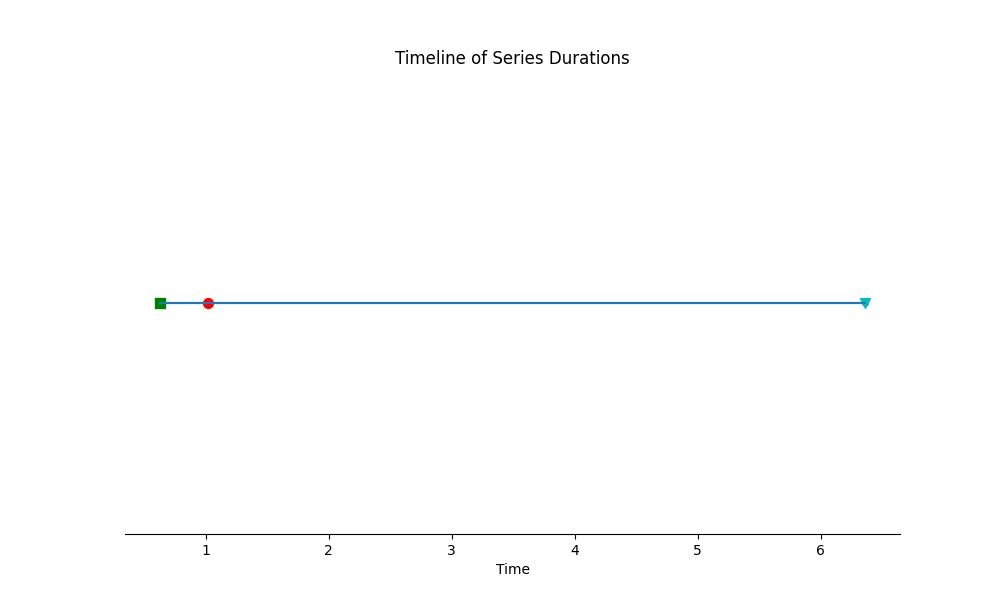

[{'clear': 2, 'end': 1714056366050, 'init': 385, 'preClear': 1714056366048, 'preInit': 1714056360349, 'preRun': 1714056360734, 'run': 5314}]


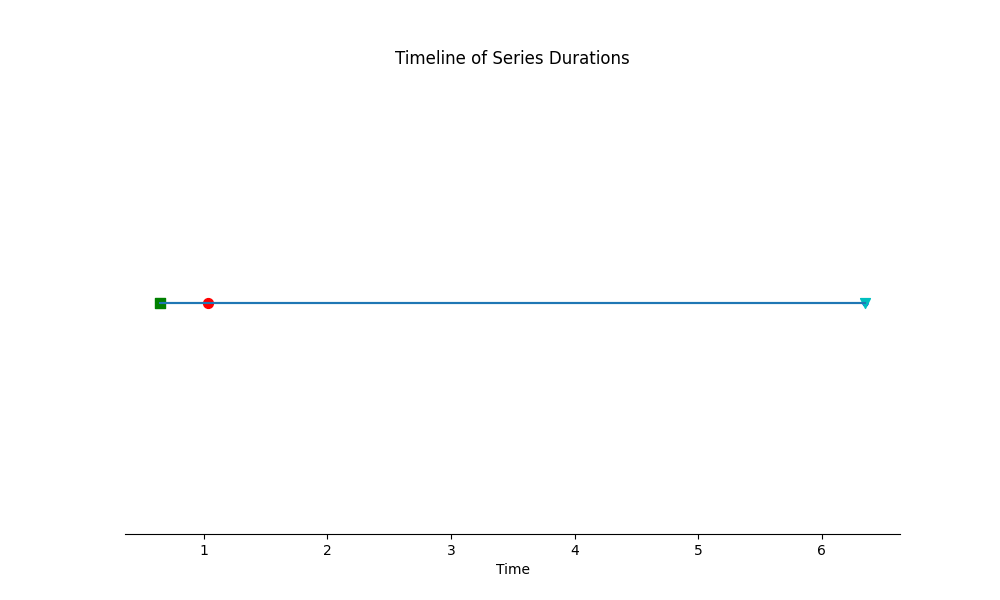

[{'clear': 2, 'end': 1714056378685, 'init': 383, 'preClear': 1714056378683, 'preInit': 1714056372918, 'preRun': 1714056373301, 'run': 5382}]


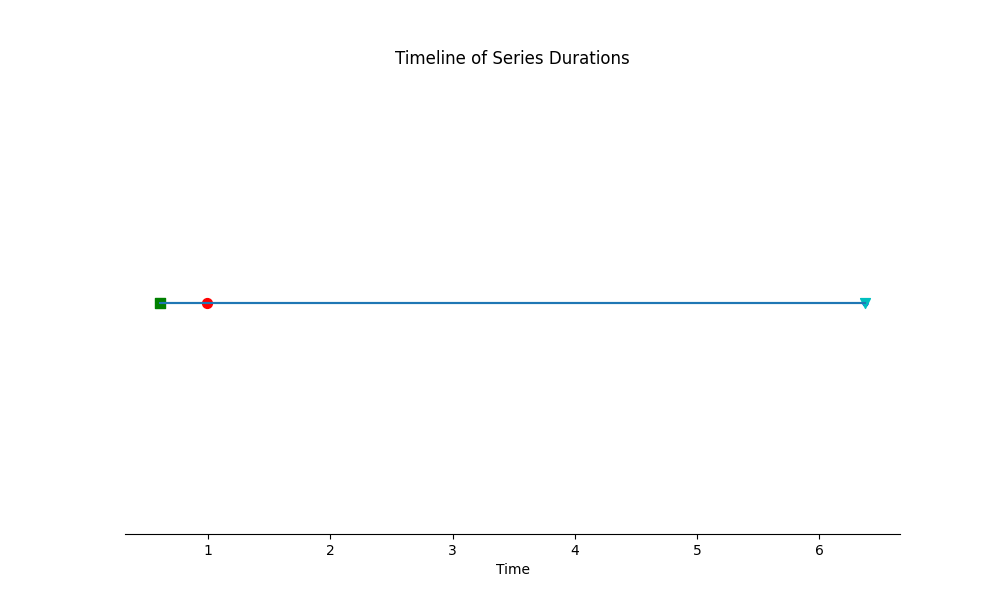

[{'clear': 2, 'end': 1714056358364, 'init': 218, 'preClear': 1714056358362, 'preInit': 1714056354618, 'preRun': 1714056354836, 'run': 3526}]


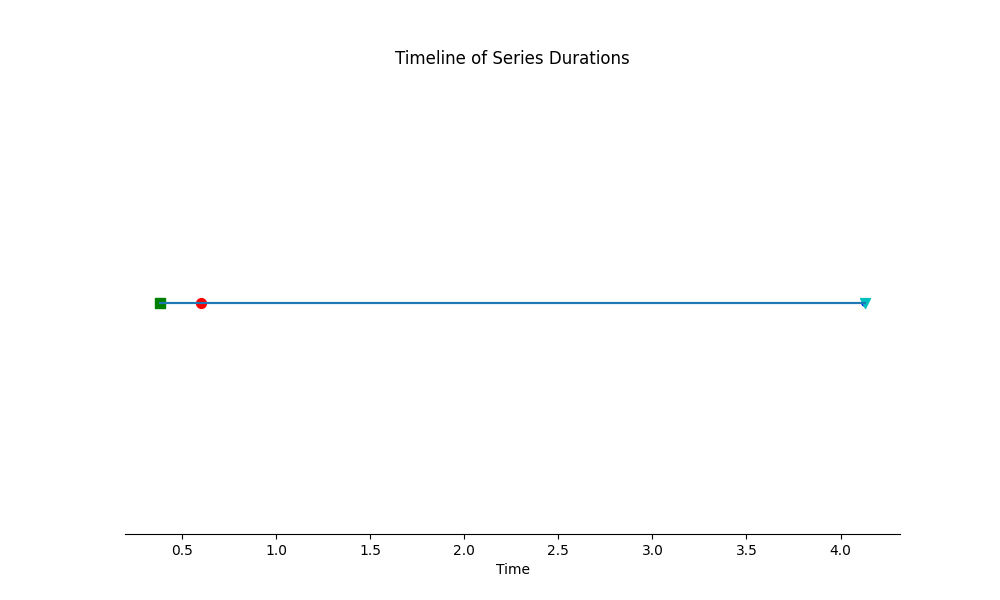

[{'clear': 2, 'end': 1714056370978, 'init': 211, 'preClear': 1714056370976, 'preInit': 1714056367167, 'preRun': 1714056367378, 'run': 3598}]


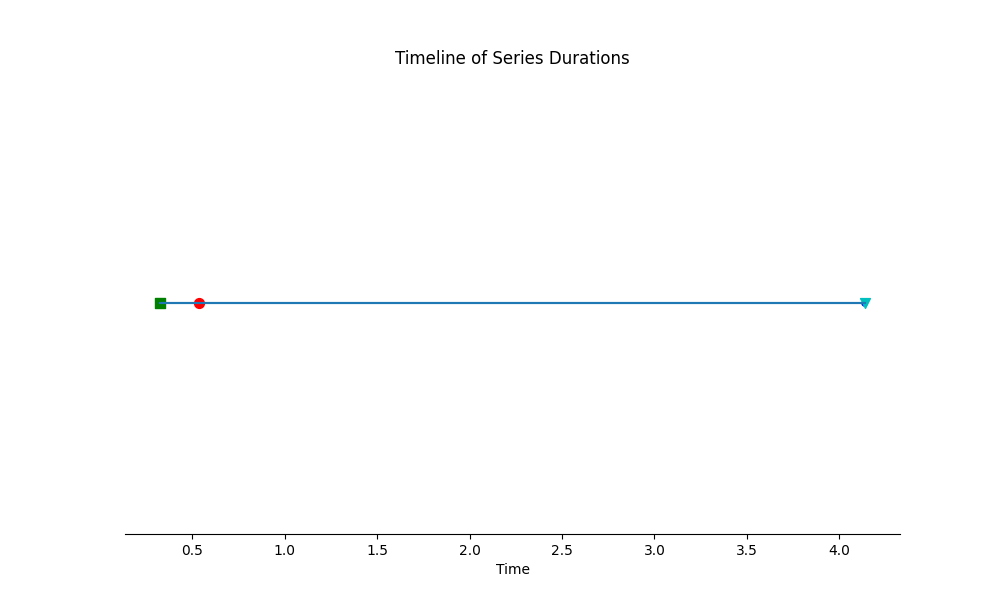

[{'clear': 3, 'end': 1714056383621, 'init': 215, 'preClear': 1714056383618, 'preInit': 1714056379781, 'preRun': 1714056379996, 'run': 3622}]


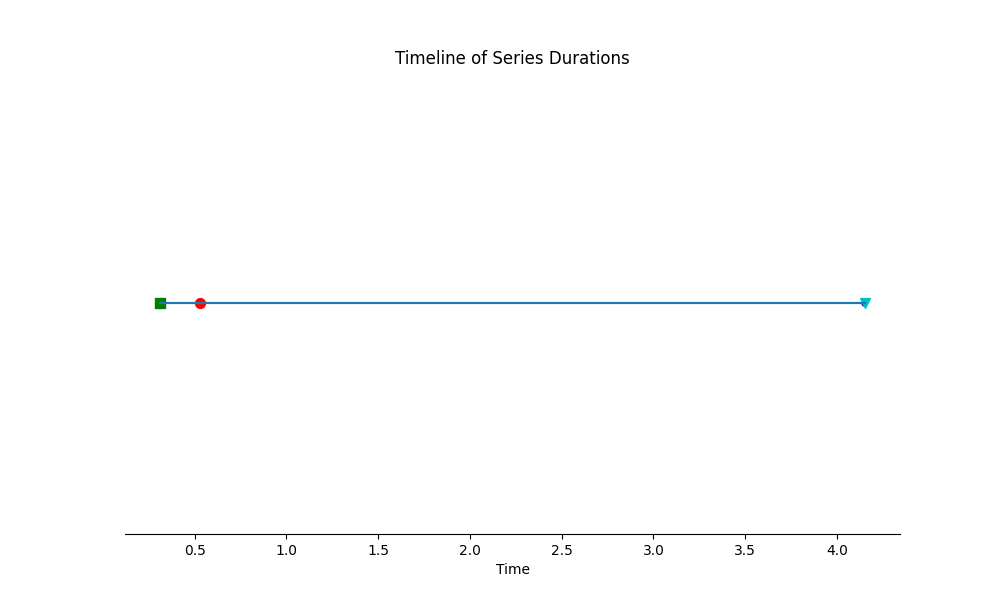

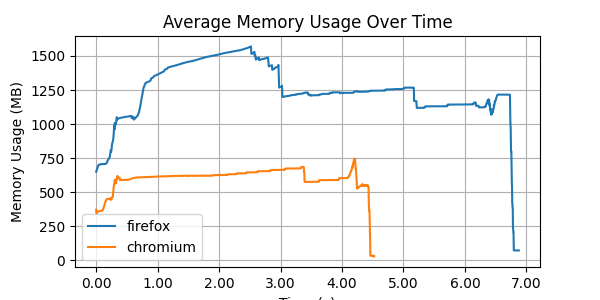

firefox - Average: Max 1569.64MB, 99th percentile: 1556.18MB, median: 1230.03MB
chromium - Average: Max 746.53MB, 99th percentile: 689.28MB, median: 619.57MB


In [21]:

runs_one_shot = plot_memory_usage('results_1_shot/thread_1')
plot_runs(runs_one_shot)

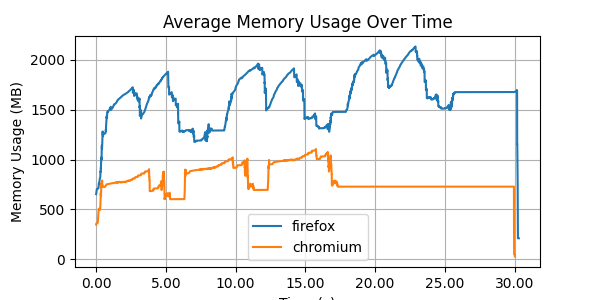

firefox - Average: Max 2133.52MB, 99th percentile: 2092.78MB, median: 1675.92MB
chromium - Average: Max 1105.00MB, 99th percentile: 1088.75MB, median: 728.59MB


In [9]:


plot_runs(plot_memory_usage('results_1_shot/thread_2'))

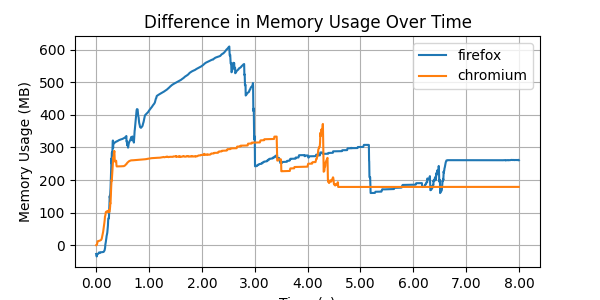

firefox - Average: Max 609.92MB, 99th percentile: 594.65MB, median: 273.03MB
chromium - Average: Max 372.32MB, 99th percentile: 333.34MB, median: 227.33MB


In [112]:
#Plot diffrence between runs




diff_runs = {}

for name in runs_empty:
    df= runs_one_shot[name] - runs_empty[name]
    # drop negative values from df
    # drop index after 15s
    df = df[df.index < pd.Timedelta(seconds=8)].interpolate(method='linear', limit_direction='both', axis=0)
    
    diff_runs[name] = df
    

plot_runs(diff_runs, title='Difference in Memory Usage Over Time')



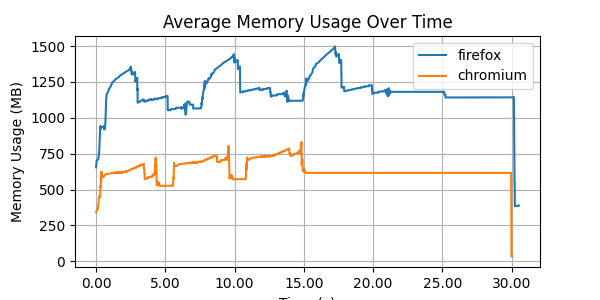

firefox - Average: Max 1497.01MB, 99th percentile: 1466.39MB, median: 1181.00MB
chromium - Average: Max 831.39MB, 99th percentile: 775.30MB, median: 616.22MB


In [119]:
runs_one_shot_repeated = plot_memory_usage('results_1_shot_repeated/thread_1')
plot_runs(runs_one_shot_repeated)